In [1]:
from Simulation.mpc import *
from Simulation.system_functions import PolymerCSTR
from utils.helpers import *

# Initializing The system

In [2]:
# First initiate the system
# Parameters
Ad = 2.142e17           # h^-1
Ed = 14897              # K
Ap = 3.816e10           # L/(molh)
Ep = 3557               # K
At = 4.50e12            # L/(molh)
Et = 843                # K
fi = 0.6                # Coefficient
m_delta_H_r = -6.99e4   # j/mol
hA = 1.05e6             # j/(Kh)
rhocp = 1506            # j/(Kh)
rhoccpc = 4043          # j/(Kh)
Mm = 104.14             # g/mol
system_params = np.array([Ad, Ed, Ap, Ep, At, Et, fi, m_delta_H_r, hA, rhocp, rhoccpc, Mm])

In [3]:
# Design Parameters
CIf = 0.5888    # mol/L
CMf = 8.6981    # mol/L
Qi = 108.       # L/h
Qs = 459.       # L/h
Tf = 330.       # K
Tcf = 295.      # K
V = 3000.       # L
Vc = 3312.4     # L

system_design_params = np.array([CIf, CMf, Qi, Qs, Tf, Tcf, V, Vc])

In [4]:
# Steady State Inputs
Qm_ss = 378.    # L/h
Qc_ss = 471.6   # L/h

system_steady_state_inputs = np.array([Qc_ss, Qm_ss])

In [5]:
# Sampling time of the system
delta_t = 0.5 # 30 mins

In [6]:
# Initiate the CSTR for steady state values
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
steady_states={"ss_inputs":cstr.ss_inputs,
               "y_ss":cstr.y_ss}

## Loading the system matrices, min max scaling, and min max of the states

In [7]:
dir_path = os.path.join(os.getcwd(), "Data")

In [8]:
# Defining the range of setpoints for data generation
setpoint_y = np.array([[2.8, 320.],
                       [5., 326.]])
u_min = np.array([71.6, 78])
u_max = np.array([870, 670])

system_data = load_and_prepare_system_data(steady_states=steady_states, setpoint_y=setpoint_y, u_min=u_min, u_max=u_max)

In [9]:
A_aug = system_data["A_aug"]
B_aug = system_data["B_aug"]
C_aug = system_data["C_aug"]

In [10]:
data_min = system_data["data_min"]
data_max = system_data["data_max"]

In [11]:
# min_max_states = system_data["min_max_states"]
# min_max_states = system_data["min_max_states"]
min_max_states = {'max_s': np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
                  'min_s': np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])}

In [12]:
y_sp_scaled_deviation = system_data["y_sp_scaled_deviation"]

In [13]:
b_min = system_data["b_min"]
b_max = system_data["b_max"]

In [14]:
min_max_dict = system_data["min_max_dict"]
min_max_dict["x_max"] = np.array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ])
min_max_dict["x_min"] = np.array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582])

In [15]:
min_max_dict

{'x_max': array([256.79686253, 256.01560603,  48.99447186, 144.79949103,
          2.82199733,   3.14014989,   2.78866348,   3.71691422,
          6.2029936 ]),
 'x_min': array([ -272.28060121, -1112.33972595,   -76.63993491,  -608.60327886,
           -3.94399122,    -3.93115257,    -2.9532091 ,    -4.06547624,
          -28.25906582]),
 'y_sp_min': array([-4.91766443, -4.61204935]),
 'y_sp_max': array([5.00776949, 3.06512771]),
 'u_max': array([9.96, 7.3 ]),
 'u_min': array([-10. ,  -7.5])}

In [16]:
# Observer Gain
poles = np.array(np.array([0.44619852, 0.33547649, 0.36380595, 0.70467118, 0.3562966,
                           0.42900673, 0.4228262 , 0.96916776, 0.91230187]))
L = compute_observer_gain(A_aug, C_aug, poles)

The system is observable.


C:\Users\HAMEDI\OneDrive - McMaster University\PythonProjects\RL_assisted_MPC_polymer\Simulation\mpc.py:124: UserWarning: Convergence was not reached after maxiter iterations.
You asked for a tolerance of 0.001, we got 0.9999999422182039.
  obs_gain_calc = signal.place_poles(A.T, C.T, desired_poles, method='KNV0')


## Setting The hyperparameters for the TD3 Agent


In [17]:
from TD3Agent.agent import TD3Agent
import torch

In [18]:
set_points_number = int(C_aug.shape[0])
inputs_number = int(B_aug.shape[1])
STATE_DIM = int(A_aug.shape[0]) + set_points_number + inputs_number
ACTION_DIM = 3 # or Matrix A nad B (Change this to a more general format)
n_outputs = C_aug.shape[0]
a_coef, b_coef, c_coef = 1, 1, 1
ACTOR_LAYER_SIZES = [512, 512, 512, 512]
CRITIC_LAYER_SIZES = [512, 512, 512, 512]
BUFFER_CAPACITY = 1000000
ACTOR_LR = 1e-4
CRITIC_LR = 1e-4
SMOOTHING_STD = 0.1
NOISE_CLIP = 0.1
EXPLORATION_NOISE_STD = 0.5
GAMMA = 0.99
TAU = 0.005
MAX_ACTION = 1
POLICY_DELAY = 2
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128
STD_START = 0.5
STD_END = 0.01
STD_DECAY_RATE = 0.99998
STD_DECAY_MODE = "exp"
ACTOR_FREEZE = 0

In [19]:
td3_agent = TD3Agent(
    state_dim=STATE_DIM,
    action_dim=ACTION_DIM,
    actor_hidden=ACTOR_LAYER_SIZES,
    critic_hidden=CRITIC_LAYER_SIZES,
    gamma=GAMMA,
    actor_lr=ACTOR_LR,
    critic_lr=CRITIC_LR,
    batch_size=BATCH_SIZE,
    policy_delay=POLICY_DELAY,
    target_policy_smoothing_noise_std=SMOOTHING_STD,
    noise_clip=NOISE_CLIP,
    max_action=MAX_ACTION,
    tau=TAU,
    std_start=STD_START,
    std_end=STD_END,
    std_decay_rate=STD_DECAY_RATE,
    std_decay_mode=STD_DECAY_MODE,
    buffer_size=BUFFER_CAPACITY,
    device=DEVICE,
    actor_freeze=ACTOR_FREEZE,
    )

## MPC initialization and setpoints

In [20]:
# MPC parameters
predict_h = 9
cont_h = 3
b1 = (b_min[0], b_max[0])
b2 = (b_min[1], b_max[1])
bnds = (b1, b2)*cont_h
cons = []
IC_opt = np.zeros(inputs_number*cont_h)
Q1_penalty = 5
Q2_penalty = 1
R1_penalty = 1
R2_penalty = 1
Q_penalty = np.array([[Q1_penalty, 0], [0, Q2_penalty]])
R_penalty = np.array([[R1_penalty, 0], [0, R2_penalty]])

In [21]:
MPC_obj = MpcSolver(A_aug, B_aug, C_aug,
                    Q1_penalty, Q2_penalty, R1_penalty, R2_penalty,
                    predict_h, cont_h)

In [22]:
y_sp_scenario = np.array([[4.5, 324],
                          [3.4, 321]])

# y_sp_scenario = np.concatenate((steady_states["y_ss"].reshape(1, -1), y_sp_scenario), axis=0)


y_sp_scenario = apply_min_max(y_sp_scenario, data_min[2:], data_max[2:]) - apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
n_tests = 200
set_points_len = 400
TEST_CYCLE = [False, False, False, False, False]
warm_start = 0

In [23]:
nominal_qs = 459
nominal_qi = 108
nominal_hA = 1.05e6
qi_change = 0.95
qs_change = 1.05
ha_change = 0.92

In [24]:
HIGH_COEF, LOW_COEF = np.array([1.05, 1.2, 1.2]), np.array([0.9, 0.8, 0.8])

In [25]:
def make_reward_fn_fixed_QR(
    data_min, data_max, n_inputs,
    y_band_phys,
    Q_diag, R_diag,
    tau_frac=0.5,
    gamma_out=0.20, gamma_in=0.30,
    beta=0.20, gate="geom", lam_in=1.0,
    bonus_kind="exp", bonus_k=8.0, bonus_p=0.6, bonus_c=20.0,
    bonus_scale_mode="qb2",
):

    data_min = np.asarray(data_min, float)
    data_max = np.asarray(data_max, float)
    dy = np.maximum(data_max[n_inputs:] - data_min[n_inputs:], 1e-12)  # phys per scaled

    y_band_phys = np.atleast_1d(np.asarray(y_band_phys, float))
    # convert plant band -> scaled band for this output scaling
    band_scaled = y_band_phys / np.maximum(dy, 1e-12)
    print(band_scaled)
    tau_scaled  = tau_frac * band_scaled

    Q_diag = np.asarray(Q_diag, float)
    R_diag = np.asarray(R_diag, float)

    qb2 = Q_diag * (band_scaled**2)


    def _sigmoid(x):
        x = np.clip(x, -60.0, 60.0)
        return 1.0/(1.0 + np.exp(-x))

    def _phi(z, kind=bonus_kind, k=bonus_k, p=bonus_p, c=bonus_c):
        z = np.clip(z, 0.0, 1.0)
        if kind == "linear":   return 1.0 - z
        if kind == "quadratic":return (1.0 - z)**2
        if kind == "exp":      return (np.exp(-k*z) - np.exp(-k)) / (1.0 - np.exp(-k))
        if kind == "power":    return 1.0 - np.power(z, p)
        if kind == "log":      return np.log1p(c*(1.0 - z)) / np.log1p(c)
        raise ValueError("unknown bonus kind")

    def reward_fn(e_scaled, du_scaled):
        e_scaled = np.asarray(e_scaled, float)
        du_scaled= np.asarray(du_scaled, float)

        # ---- gating computed in *scaled* space (no plant conversion) ----
        abs_e = np.abs(e_scaled)
        s_i   = _sigmoid((band_scaled - abs_e) / np.maximum(tau_scaled, 1e-12))
        if gate == "prod":
            w_in = float(np.prod(s_i, dtype=np.float64))
        elif gate == "mean":
            w_in = float(np.mean(s_i))
        elif gate == "geom":
            w_in = float(np.prod(s_i, dtype=np.float64) ** (1.0/len(s_i)))
        else:
            raise ValueError("gate must be 'prod'|'mean'|'geom'")

        # ---- core MPC-like terms (scaled space) ----
        err_quad = np.sum(Q_diag * (e_scaled**2))
        err_eff  = (1.0 - w_in) * err_quad + w_in * (lam_in * err_quad)   # lam_in=1 -> no relief
        move     = np.sum(R_diag * (du_scaled**2))

        # ---- linear penalties calibrated by slope at the band edge ----
        # slope_i at |e|=b_i is 2 * Q_i * b_i  (same units as derivative of quadratic)
        slope_at_edge = 2.0 * Q_diag * band_scaled

        # outside: penalize only the overflow above the band
        overflow = np.maximum(abs_e - band_scaled, 0.0)
        lin_out  = (1.0 - w_in) * np.sum(gamma_out * slope_at_edge * overflow)

        # inside: penalize |e| linearly (optionally cap at b for stability)
        inside_mag = np.minimum(abs_e, band_scaled)
        lin_in     = w_in * np.sum(gamma_in * slope_at_edge * inside_mag)

        # ---- sharp inside bonus (dimensionless) using normalized scaled z = |e|/band ----
        z = abs_e / np.maximum(band_scaled, 1e-12)
        phi = _phi(z, kind=bonus_kind, k=bonus_k, p=bonus_p, c=bonus_c)
        bonus = w_in * beta * np.sum(qb2 * phi)

        return -(err_eff + move + lin_out + lin_in) + bonus

    return (
        dict(Q_diag=Q_diag, R_diag=R_diag, band_scaled=band_scaled, tau_scaled=tau_scaled,
             gamma_out=gamma_out, gamma_in=gamma_in, beta=beta, gate=gate, lam_in=lam_in,
             bonus_kind=bonus_kind, bonus_k=bonus_k, bonus_p=bonus_p, bonus_c=bonus_c,
             bonus_scale_mode=bonus_scale_mode),
        reward_fn
    )

In [26]:
Q_diag = np.array([5.0, 1.0])
R_diag = np.array([1.0, 1.0])

y_band_phys = np.array([0.1, 0.1])
# y_band_phys = np.array([0.005, 0.1])
print("Band scaled are:")

params, reward_fn = make_reward_fn_fixed_QR(
        data_min, data_max, inputs_number,
        y_band_phys,
        Q_diag, R_diag,
        tau_frac=0.7,
        gamma_out=.7, gamma_in=.7,
        beta=50., gate="geom", lam_in=1.0,
        bonus_kind="exp", bonus_k=3.0, bonus_p=0.6, bonus_c=20.0)
print(params)

Band scaled are:
[0.45115609 0.12795295]
{'Q_diag': array([5., 1.]), 'R_diag': array([1., 1.]), 'band_scaled': array([0.45115609, 0.12795295]), 'tau_scaled': array([0.31580926, 0.08956707]), 'gamma_out': 0.7, 'gamma_in': 0.7, 'beta': 50.0, 'gate': 'geom', 'lam_in': 1.0, 'bonus_kind': 'exp', 'bonus_k': 3.0, 'bonus_p': 0.6, 'bonus_c': 20.0, 'bonus_scale_mode': 'qb2'}


In [27]:
def run_rl_train_disturbance_gradually(
        system, y_sp_scenario, n_tests, set_points_len,
        steady_states, min_max_dict, agent, MPC_obj,
        Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L,
        data_min, data_max, warm_start,
        test_cycle, nominal_qi, nominal_qs, nominal_ha,
        qi_change, qs_change, ha_change,
        high_coef, low_coef, reward_fn
):

    # --- setpoints generation ---
    y_sp, nFE, sub_episodes_changes_dict, time_in_sub_episodes, test_train_dict, WARM_START, qi, qs, ha = \
        generate_setpoints_training_rl_gradually(
            y_sp_scenario, n_tests, set_points_len, warm_start, test_cycle,
            nominal_qi, nominal_qs, nominal_ha,
            qi_change, qs_change, ha_change
        )

    # inputs and outputs of the system dimensions
    n_inputs = B_aug.shape[1]
    n_outputs = C_aug.shape[0]
    n_states = A_aug.shape[0]

    # Scaled steady states inputs and outputs
    ss_scaled_inputs = apply_min_max(steady_states["ss_inputs"], data_min[:n_inputs], data_max[:n_inputs])
    y_ss_scaled = apply_min_max(steady_states["y_ss"], data_min[n_inputs:], data_max[n_inputs:])

    # Logs
    y_system = np.zeros((nFE + 1, n_outputs))
    y_system[0, :] = system.current_output
    u_mpc = np.zeros((nFE, n_inputs))
    rewards = np.zeros(nFE)
    avg_rewards = []
    yhat = np.zeros((n_outputs, nFE))
    xhatdhat = np.zeros((n_states, nFE + 1))
    xhatdhat[:, 0] = np.random.uniform(low=min_max_dict["x_min"], high=min_max_dict["x_max"])

    # multipliers
    multiplier_coefs_alpha = np.zeros((nFE + 1, 1))
    multiplier_coefs_delta = np.zeros((nFE + 1, n_inputs))

    # Keep immutable baselines for model scaling (avoid cumulative drift)
    A_base = MPC_obj.A.copy()
    B_base = MPC_obj.B.copy()

    # ----- helper ------
    def map_to_bounds(a, low, high):
        return low + ((a + 1.0) / 2.0) * (high - low)

    for i in range(nFE):
        # train/test phase
        if i in test_train_dict:
            test = test_train_dict[i]

        # Current scaled input & deviation
        scaled_current_input = apply_min_max(system.current_input, data_min[:n_inputs], data_max[:n_inputs])
        scaled_current_input_dev = scaled_current_input - ss_scaled_inputs

        # ---- RL state (scaled) ----
        current_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i], y_sp[i, :], scaled_current_input_dev).astype(np.float32)

        # Solve MPC for current y_sp and model state x0_model
        sol = spo.minimize(
            lambda x: MPC_obj.mpc_opt_fun(x, y_sp[i, :], scaled_current_input_dev, xhatdhat[:, i]),
            IC_opt, bounds=bnds, constraints=cons
        )

        # ---- TD3 action ----
        action = agent.take_action(current_rl_state, explore=(not test))
        # Map to bounds
        action_mapped = map_to_bounds(action, low_coef, high_coef)
        alpha, delta = action_mapped[:-n_inputs], action_mapped[-n_inputs:]

        multiplier_coefs_alpha[i] = alpha
        multiplier_coefs_delta[i] = delta

        # ---- apply model scaling (from baselines each step) ----
        A_change = A_base.copy()
        B_change = B_base.copy()
        n_phys = n_states - n_outputs
        A_change[:n_phys, :n_phys] *= alpha
        B_change[:n_phys, :] *= delta.reshape(1, -1)

        MPC_obj.A = A_change
        MPC_obj.B = B_change

        # Take first move (scaled deviation) and map to plant input
        u_mpc[i, :] = sol.x[:n_inputs] + ss_scaled_inputs
        u_plant = reverse_min_max(u_mpc[i, :], data_min[:n_inputs], data_max[:n_inputs])

        # delta u cost variables
        delta_u = u_mpc[i, :] - scaled_current_input

        # Apply to plant and step
        system.current_input = u_plant
        system.step()
        # disturbances
        system.hA = ha[i]
        system.Qs = qs[i]
        system.Qi = qi[i]

        # Record output
        y_system[i+1, :] = system.current_output

        # ----- Observer & model roll -----
        y_current_scaled = apply_min_max(y_system[i+1, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled
        y_prev_scaled = apply_min_max(y_system[i, :], data_min[n_inputs:], data_max[n_inputs:]) - y_ss_scaled

        # Calculate Delta y in deviation form
        delta_y = y_current_scaled - y_sp[i, :]

        # Calculate the next state in deviation form
        yhat[:, i] = np.dot(MPC_obj.C, xhatdhat[:, i])
        xhatdhat[:, i+1] = np.dot(MPC_obj.A, xhatdhat[:, i]) + np.dot(MPC_obj.B, (u_mpc[i, :] - ss_scaled_inputs)) + np.dot(L, (y_prev_scaled - yhat[:, i])).T

        # # Reward Calculation
        # reward = - (Q1_penalty * delta_y[0] ** 2 + Q2_penalty * delta_y[1] ** 2 +
        #             R1_penalty * delta_u[0] ** 2 + R2_penalty * delta_u[1] ** 2)
        #
        # # Record rewards
        # rewards[i] = reward
        # Reward Calculation
        reward = reward_fn(delta_y, delta_u)

        # Record rewards and delta_y
        rewards[i] = reward

        # ----- Next state for TD3 -----
        next_u_dev = u_mpc[i, :] - ss_scaled_inputs
        next_rl_state = apply_rl_scaled(min_max_dict, xhatdhat[:, i+1], y_sp[i, :], next_u_dev)

        # Episode boundary (treat each setpoint block as an episode end)
        done = ((i + 1) % time_in_sub_episodes == 0) or (i == nFE - 1)

        # Buffer + train (skip if in test phase)
        if not test:
            agent.push(current_rl_state,
                       action.astype(np.float32),
                       float(reward),
                       next_rl_state,
                       float(done))
            if i >= WARM_START:
                _ = agent.train_step()  # returns loss or None

        # diagnostics at sub-episode boundary
        if i in sub_episodes_changes_dict:
            avg_rewards.append(np.mean(rewards[max(0, i - time_in_sub_episodes + 1): i + 1]))
            print('Sub_Episode:', sub_episodes_changes_dict[i], '| avg. reward:', avg_rewards[-1])
            print('Avg scalers -> A:', np.mean(multiplier_coefs_alpha[max(0, i - time_in_sub_episodes + 1): i+1, 0]),
                  ' B:', np.mean(multiplier_coefs_delta[max(0, i - time_in_sub_episodes + 1): i+1, :], axis=0))
            if hasattr(agent, "_expl_sigma"):
                print('Exploration noise:', agent._expl_sigma)

    # Reverse scaling for RL inputs
    u_rl = reverse_min_max(u_mpc, data_min[:n_inputs], data_max[:n_inputs])

    return (y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
            y_sp, yhat, qi, qs, ha, multiplier_coefs_alpha, multiplier_coefs_delta)

In [28]:
cstr = PolymerCSTR(system_params, system_design_params, system_steady_state_inputs, delta_t)
(y_system, u_rl, avg_rewards, rewards, xhatdhat, nFE, time_in_sub_episodes,
            y_sp, yhat, qi, qs, ha, multiplier_coefs_alpha, multiplier_coefs_delta) = run_rl_train_disturbance_gradually(cstr, y_sp_scenario, n_tests, set_points_len,
        steady_states, min_max_dict, td3_agent, MPC_obj,
        Q1_penalty, Q2_penalty, R1_penalty, R2_penalty, L,
        data_min, data_max, warm_start,
        TEST_CYCLE, nominal_qi, nominal_qs, nominal_hA,
        qi_change, qs_change, ha_change,
        HIGH_COEF, LOW_COEF, reward_fn
)

Sub_Episode: 1 | avg. reward: 17.432517438779648
Avg scalers -> A: 0.9673197203325102  B: [1.02183639 1.01579413]
Exploration noise: 0.49222230967047753
Sub_Episode: 2 | avg. reward: 16.461663987616006
Avg scalers -> A: 0.976229091527664  B: [0.9844745  1.00538443]
Exploration noise: 0.484568073354959
Sub_Episode: 3 | avg. reward: 18.56186767725471
Avg scalers -> A: 0.9789816466002199  B: [0.99199022 1.09643653]
Exploration noise: 0.4770353314879529
Sub_Episode: 4 | avg. reward: 17.955233152853083
Avg scalers -> A: 0.9762529496639254  B: [0.9963418 1.0888738]
Exploration noise: 0.4696221556078321
Sub_Episode: 5 | avg. reward: 18.826056514889142
Avg scalers -> A: 0.970224112002327  B: [1.03178322 1.13351253]
Exploration noise: 0.46232664786312744
Sub_Episode: 6 | avg. reward: 14.404843454921075
Avg scalers -> A: 0.9810414935193953  B: [0.91653741 1.15122334]
Exploration noise: 0.4551469405266573
Sub_Episode: 7 | avg. reward: 13.834756240590023
Avg scalers -> A: 0.9780761151657661  B: [0

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rl_results_td3(
    y_sp,                # scaled-deviation setpoints, shape [nFE, ny]
    steady_states,       # {"y_ss": ...}
    nFE,                 # steps
    delta_t,             # hours/step
    time_in_sub_episodes,# block length (steps)
    y_mpc,               # ORIGINAL units, shape [nFE+1, ny]   (y_system)
    u_mpc,               # ORIGINAL units, shape [nFE, nu]     (u_rl)
    avg_rewards,         # list/array
    data_min, data_max,  # scaling arrays
    # Optional extras
    horizon_trace=None,                 # [nFE, 2] (Hp, Hc)
    coef_alpha=None,                    # [nFE] or [nFE+1, 1] : α_t (A-scale)
    coef_delta=None,                    # [nFE, nu] or [nFE+1, nu] : δ_t per input (B-scale)
    high_coef=None, low_coef=None,      # arrays like [α, δ1, δ2, ...]
    recipe_counts=False,
    mpc_baseline=None                   # (Hp0, Hc0) -> red bar in histogram
):
    """
    Presentation-ready version:
      - Legends removed everywhere.
      - Bold labels/ticks, thicker lines.
      - Optional horizon-usage histogram highlights (Hp,Hc)==mpc_baseline in red.
    """

    # --- Global presentation style ---
    plt.rcParams.update({
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "mathtext.default": "regular"
    })
    LW, MS = 3.0, 6

    def _style(ax, xlabel=None, ylabel=None):
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=20, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.margins(x=0.01)

    ny = y_mpc.shape[1]
    nu = u_mpc.shape[1]

    # ----- Unscale setpoints back to original units -----
    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp_full = reverse_min_max(y_sp + y_ss, data_min[2:], data_max[2:]).T  # [ny, nFE]

    # ----- Time axes -----
    time_full   = np.linspace(0, nFE * delta_t, nFE + 1)                 # outputs (nFE+1)
    time_full_u = np.linspace(0, (nFE-1) * delta_t, nFE)                 # inputs (nFE)
    s0 = nFE - time_in_sub_episodes
    time_block   = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes + 1)
    time_block_u = np.linspace(0, (time_in_sub_episodes-1) * delta_t, time_in_sub_episodes)

    # =========================
    # 1) Outputs vs Setpoints (full)
    # =========================
    fig, axs = plt.subplots(2 if ny >= 2 else 1, 1, figsize=(11, 9), sharex=True)
    if ny < 2: axs = [axs]

    axs[0].plot(time_full, y_mpc[:, 0], lw=LW)
    axs[0].step(time_full[:-1], y_sp_full[0, :], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    if ny >= 2:
        axs[1].plot(time_full, y_mpc[:, 1], lw=LW)
        axs[1].step(time_full[:-1], y_sp_full[1, :], where='post', linestyle='--', lw=LW)
        _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')
    else:
        _style(axs[0], xlabel=r'$\mathbf{Time}$ (hour)')

    fig.tight_layout(); plt.show()

    # =========================
    # 2) Outputs vs Setpoints (last block)
    # =========================
    fig, axs = plt.subplots(2 if ny >= 2 else 1, 1, figsize=(11, 9), sharex=True)
    if ny < 2: axs = [axs]

    axs[0].plot(time_block, y_mpc[s0:, 0], lw=LW)
    axs[0].step(time_block[:-1], y_sp_full[0, s0:], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    if ny >= 2:
        axs[1].plot(time_block, y_mpc[s0:, 1], lw=LW)
        axs[1].step(time_block[:-1], y_sp_full[1, s0:], where='post', linestyle='--', lw=LW)
        _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')
    else:
        _style(axs[0], xlabel=r'$\mathbf{Time}$ (hour)')

    fig.tight_layout(); plt.show()

    # =========================
    # 3) Inputs (Qc, Qm, ...)
    # =========================
    fig, axs = plt.subplots(nu, 1, figsize=(11, 9), sharex=True)
    if nu == 1: axs = [axs]
    for j in range(nu):
        axs[j].step(time_full_u, u_mpc[:, j], where='post', lw=LW)
        _style(axs[j], ylabel=fr'$u_{j+1}$' + ' (orig units)' if j == 0 else fr'$u_{j+1}$')
    _style(axs[-1], xlabel=r'$\mathbf{Time}$ (hour)')
    fig.tight_layout(); plt.show()

    # =========================
    # 4) Avg reward per block
    # =========================
    if len(avg_rewards) > 0:
        plt.figure(figsize=(10, 7))
        plt.plot(np.arange(1, len(avg_rewards) + 1), avg_rewards, 'o-', lw=LW, markersize=MS)
        plt.ylabel(r'Avg. Reward', fontsize=20, fontweight='bold')
        plt.xlabel(r'Episode #', fontsize=20, fontweight='bold')
        plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        plt.tight_layout(); plt.show()

    # =========================
    # 5) Horizons (Hp, Hc) over time (optional)
    # =========================
    if horizon_trace is not None:
        Hp = horizon_trace[:, 0].astype(int)
        Hc = horizon_trace[:, 1].astype(int)

        # full timeline
        fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
        axs[0].step(time_full_u, Hp, where='post', lw=LW)
        _style(axs[0], ylabel='Prediction Horizon (steps)')

        axs[1].step(time_full_u, Hc, where='post', lw=LW)
        _style(axs[1], xlabel='Time (hour)', ylabel='Control Horizon (steps)')
        fig.tight_layout(); plt.show()

        # last block
        fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
        axs[0].step(time_block_u, Hp[s0:], where='post', lw=LW)
        _style(axs[0], ylabel='Prediction Horizon (steps)')

        axs[1].step(time_block_u, Hc[s0:], where='post', lw=LW)
        _style(axs[1], xlabel='Time (hour)', ylabel='Control Horizon (steps)')
        fig.tight_layout(); plt.show()

        # optional usage histogram
        if recipe_counts:
            import collections
            counts = collections.Counter(list(zip(Hp, Hc)))
            pairs, freqs = zip(*sorted(counts.items(), key=lambda x: (-x[1], x[0])))
            top_k = 20
            pairs, freqs = pairs[:top_k], freqs[:top_k]

            colors = ['0.5'] * len(freqs)  # gray
            if mpc_baseline is not None:
                for i, p in enumerate(pairs):
                    if (p[0] == mpc_baseline[0]) and (p[1] == mpc_baseline[1]):
                        colors[i] = 'red'

            x = np.arange(len(freqs))
            plt.figure(figsize=(12, 7))
            plt.bar(x, freqs, color=colors, edgecolor='black', linewidth=1.0)
            labels = [f"Hp={p[0]}, Hc={p[1]}" for p in pairs]
            plt.xticks(x, labels, rotation=35, ha='right', fontsize=16, fontweight='bold')
            plt.ylabel('Count', fontsize=20, fontweight='bold')
            plt.title('Horizon Pair Usage', fontsize=22, fontweight='bold')
            plt.grid(axis='y', linestyle='--', alpha=0.5)
            plt.tight_layout(); plt.show()

    # =========================
    # 6) Coefficient multipliers (α for A, δ_j for B)
    # =========================
    if coef_alpha is not None or coef_delta is not None:
        # slice to nFE for alignment with input timeline
        alpha = None
        if coef_alpha is not None:
            alpha = np.asarray(coef_alpha).reshape(-1)[:nFE]

        delta = None
        if coef_delta is not None:
            delta = np.asarray(coef_delta)
            if delta.shape[0] > nFE:
                delta = delta[:nFE, :]

        have_bounds = (high_coef is not None) and (low_coef is not None)
        if have_bounds:
            high_coef = np.asarray(high_coef).reshape(-1)
            low_coef  = np.asarray(low_coef).reshape(-1)
            # Expect [α, δ1..δnu] or [1] if only α is used
            assert (high_coef.size == low_coef.size) and (
                   (high_coef.size == 1 + nu) or (high_coef.size == 1 and delta is None)), \
                   "high/low bounds must be shape [1+nu] (α plus per-input δ)."

        rows = (1 if alpha is not None else 0) + (delta.shape[1] if delta is not None else 0)
        rows = max(1, rows)
        fig, axs = plt.subplots(rows, 1, figsize=(11, max(7, 2.7*rows)), sharex=True)
        if rows == 1: axs = [axs]
        r = 0

        # α panel
        if alpha is not None:
            ax = axs[r]
            if have_bounds:
                ax.fill_between(time_full_u, low_coef[0], high_coef[0], alpha=0.15, step='post')
                ax.hlines([low_coef[0], high_coef[0]], time_full_u[0], time_full_u[-1],
                          linestyles='--', linewidth=1.0)
            ax.step(time_full_u, alpha, where='post', lw=LW)
            _style(ax, ylabel=r'$\alpha$')
            r += 1

        # δ panels
        if delta is not None:
            for j in range(delta.shape[1]):
                ax = axs[r]
                if have_bounds and high_coef.size >= 1+nu:
                    lo, hi = low_coef[1+j], high_coef[1+j]
                    ax.fill_between(time_full_u, lo, hi, alpha=0.15, step='post')
                    ax.hlines([lo, hi], time_full_u[0], time_full_u[-1], linestyles='--', linewidth=1.0)
                ax.step(time_full_u, delta[:, j], where='post', lw=LW)
                _style(ax, ylabel=fr'$\beta_{j+1}$')
                r += 1

        _style(axs[-1], xlabel='Time (hour)')
        fig.tight_layout(); plt.show()

        # --- last block view ---
        L = time_in_sub_episodes
        if L > 0:
            fig, axs = plt.subplots(rows, 1, figsize=(11, max(7, 2.7*rows)), sharex=True)
            if rows == 1: axs = [axs]
            r = 0

            if alpha is not None:
                ax = axs[r]
                if have_bounds:
                    ax.fill_between(time_block_u, low_coef[0], high_coef[0], alpha=0.15, step='post')
                    ax.hlines([low_coef[0], high_coef[0]], time_block_u[0], time_block_u[-1],
                              linestyles='--', linewidth=1.0)
                ax.step(time_block_u, alpha[s0:], where='post', lw=LW)
                _style(ax, ylabel=r'$\alpha$')
                r += 1

            if delta is not None:
                for j in range(delta.shape[1]):
                    ax = axs[r]
                    if have_bounds and high_coef.size >= 1+nu:
                        lo, hi = low_coef[1+j], high_coef[1+j]
                        ax.fill_between(time_block_u, lo, hi, alpha=0.15, step='post')
                        ax.hlines([lo, hi], time_block_u[0], time_block_u[-1], linestyles='--', linewidth=1.0)
                    ax.step(time_block_u, delta[s0:, j], where='post', lw=LW)
                    _style(ax, ylabel=fr'$\beta_{j+1}$')
                    r += 1

            _style(axs[-1], xlabel='Time (hour)')
            fig.tight_layout(); plt.show()


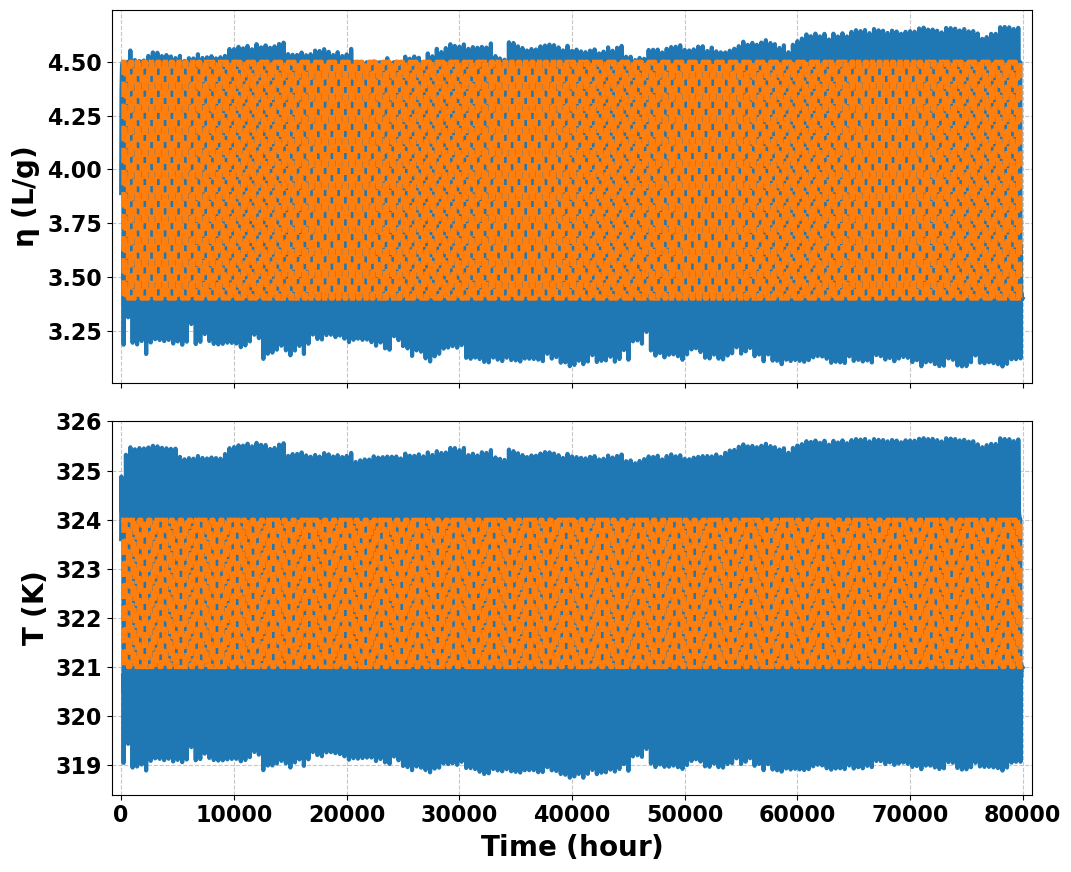

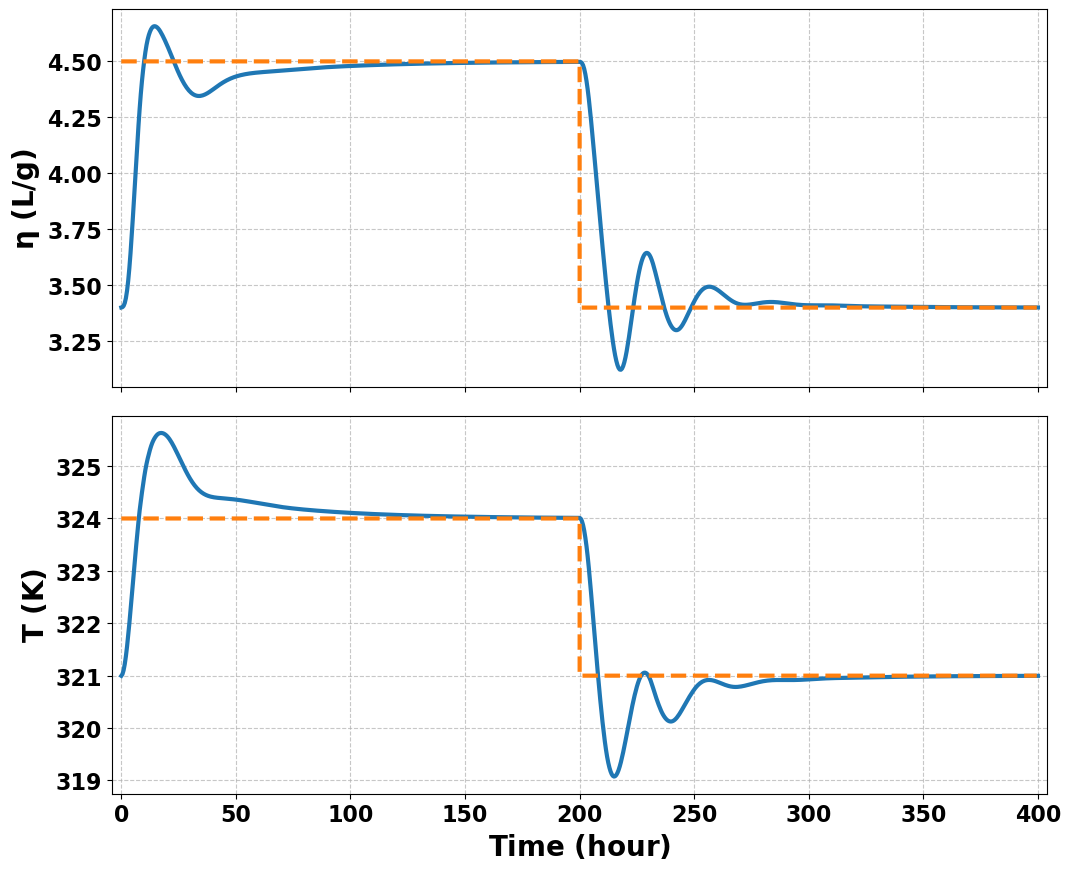

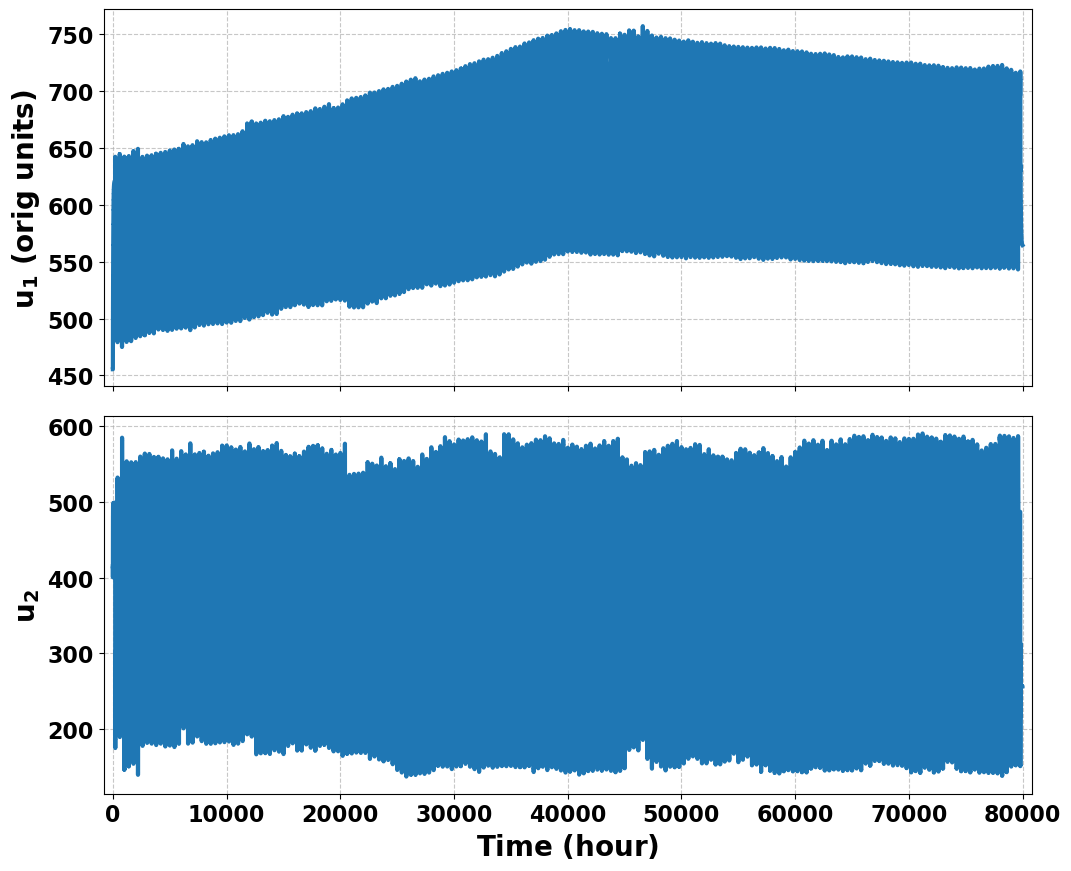

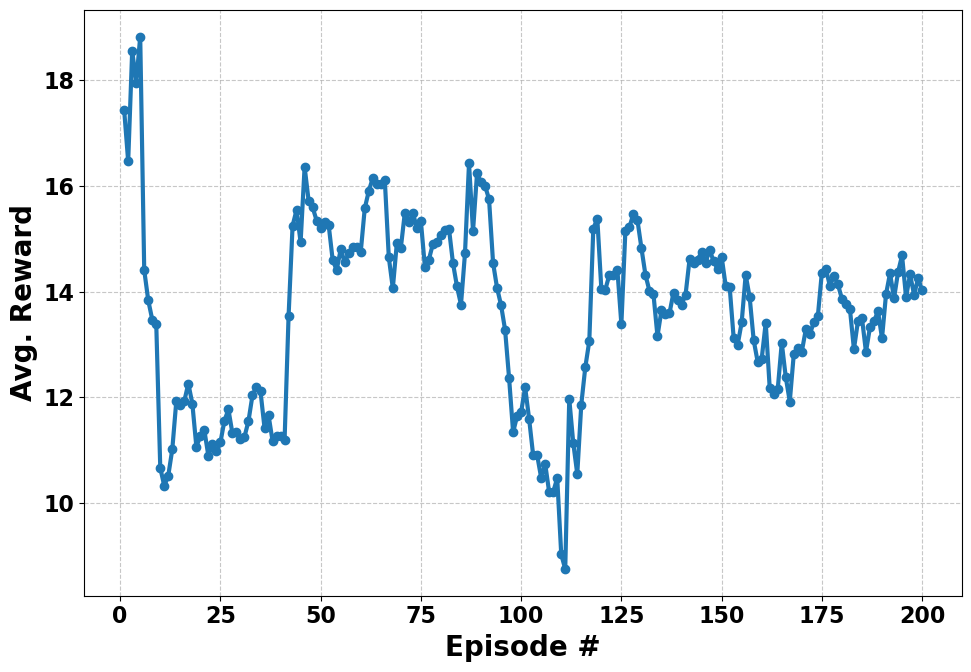

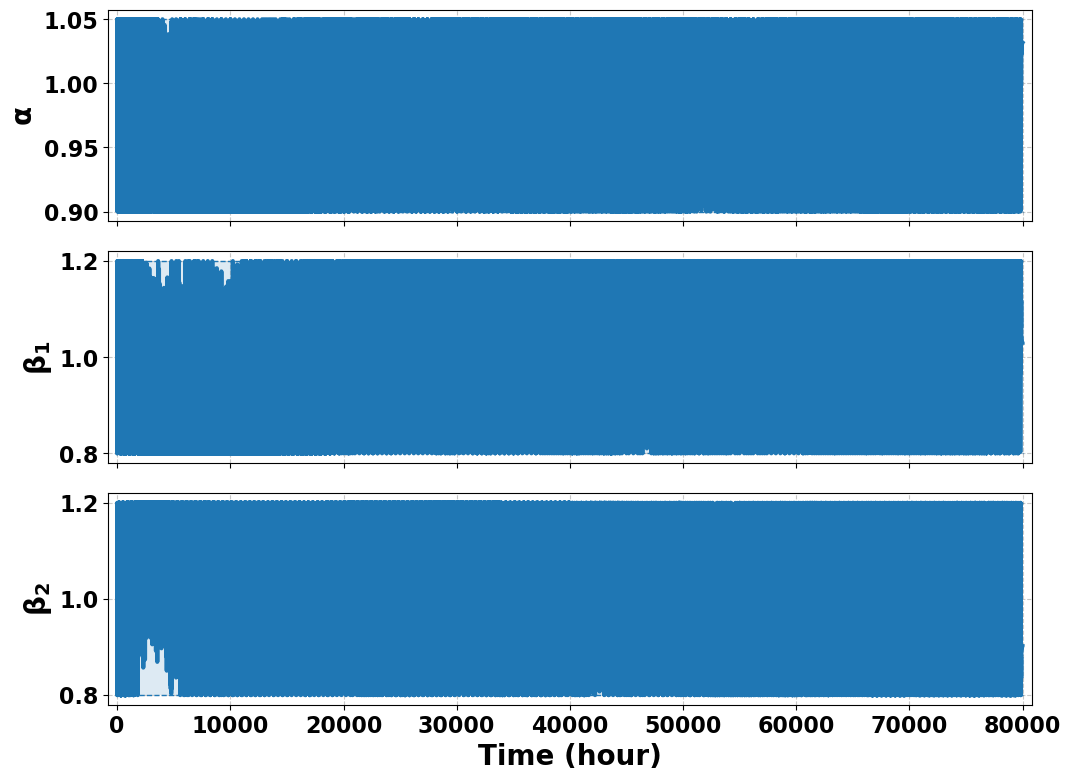

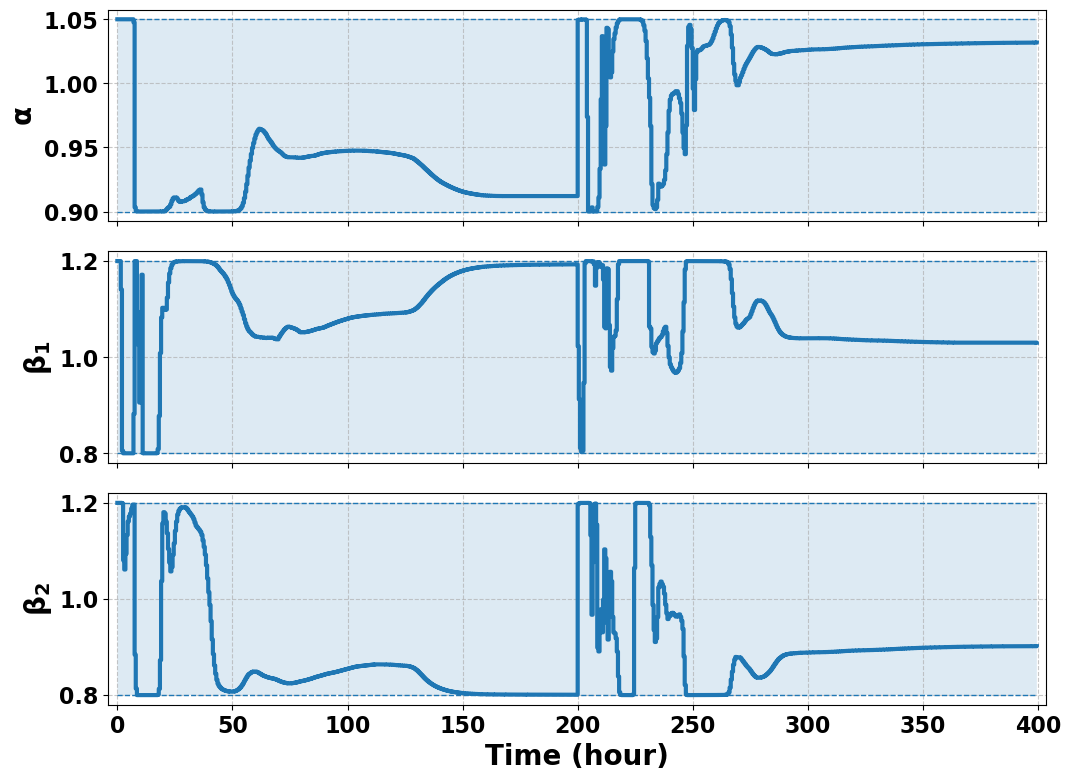

In [30]:
plot_rl_results_td3(
    y_sp=y_sp, steady_states=steady_states,
    nFE=nFE, delta_t=delta_t, time_in_sub_episodes=time_in_sub_episodes,
    y_mpc=y_system, u_mpc=u_rl, avg_rewards=avg_rewards,
    data_min=data_min, data_max=data_max,
    horizon_trace=None,  # or your horizon array if you have it
    coef_alpha=multiplier_coefs_alpha[:, 0],     # from your run loop
    coef_delta=multiplier_coefs_delta[:, :],     # shape [nFE(+1), nu]
    high_coef=HIGH_COEF, low_coef=LOW_COEF,
    recipe_counts=False
)


In [31]:
def compare_mpc_rl_disturbance(y_rl, y_mpc, y_sp, avg_rewards_rl, avg_rewards_mpc, time_in_sub_episodes, delta_t):

    y_ss = apply_min_max(steady_states["y_ss"], data_min[2:], data_max[2:])
    y_sp = (y_sp + y_ss)
    y_sp = (reverse_min_max(y_sp, data_min[2:], data_max[2:]))

    # --- Plot the "last portion" (time_in_sub_episodes) ---
    # Convert those steps to their own time axis
    time_plot_sub = np.linspace(0, time_in_sub_episodes * delta_t, time_in_sub_episodes)
    s0 = -800

        # --- Global presentation style ---
    plt.rcParams.update({
        "font.size": 16,
        "axes.labelsize": 20,
        "axes.labelweight": "bold",
        "axes.titlesize": 22,
        "xtick.labelsize": 16,
        "ytick.labelsize": 16,
        "mathtext.default": "regular"
    })
    LW, MS = 3.0, 6

    def _style(ax, xlabel=None, ylabel=None):
        if ylabel is not None:
            ax.set_ylabel(ylabel, fontsize=20, fontweight='bold')
        if xlabel is not None:
            ax.set_xlabel(xlabel, fontsize=20, fontweight='bold')
        ax.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
        ax.tick_params(axis='both', labelsize=16)
        ax.margins(x=0.01)

    # =========================
    # 1) Last block: y[:,0] and y[:,1]
    # =========================
    fig, axs = plt.subplots(2, 1, figsize=(11, 9), sharex=True)

    # Top subplot: CV1
    axs[0].plot(time_plot_sub, y_rl[s0:, 0], lw=LW)
    axs[0].plot(time_plot_sub, y_mpc[s0:, 0], linestyle='--', lw=LW)
    # Setpoint as a step (post) with same x-sampling
    axs[0].step(time_plot_sub, y_sp[s0:, 0], where='post', linestyle='--', lw=LW)
    _style(axs[0], ylabel=r'$\mathbf{\eta}$ (L/g)')

    # Bottom subplot: CV2
    axs[1].plot(time_plot_sub, y_rl[s0:, 1], lw=LW)
    axs[1].plot(time_plot_sub, y_mpc[s0:, 1], linestyle='--', lw=LW)
    axs[1].step(time_plot_sub, y_sp[s0:, 1], where='post', linestyle='--', lw=LW)
    _style(axs[1], xlabel=r'$\mathbf{Time}$ (hour)', ylabel=r'$\mathbf{T}$ (K)')

    fig.tight_layout()
    plt.show()

    # =========================
    # 2) Average rewards per episode
    # =========================
    plt.figure(figsize=(11, 9))
    x_rl = np.arange(1, len(avg_rewards_rl) + 1)
    x_mpc = np.arange(1, len(avg_rewards_mpc) + 1)

    plt.plot(x_rl, avg_rewards_rl, 'o-', lw=LW, markersize=MS)
    plt.plot(x_mpc, avg_rewards_mpc, 'o--', lw=LW, markersize=MS)
    plt.ylabel(r'Avg. Reward', fontsize=20, fontweight='bold')
    plt.xlabel(r'Episode #', fontsize=20, fontweight='bold')
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.7)
    plt.tight_layout()
    plt.show()

In [32]:
save_path = os.path.join(dir_path, "mpc_results_disturbance.pickle")
with open(save_path, 'rb') as file:
    mpc_results = pickle.load(file)
y_mpc = mpc_results["y_mpc"]
u_mpc = mpc_results["u_mpc"]
xhatdhat_mpc = mpc_results["xhatdhat"]
avg_rewards_mpc = mpc_results["avg_rewards"]

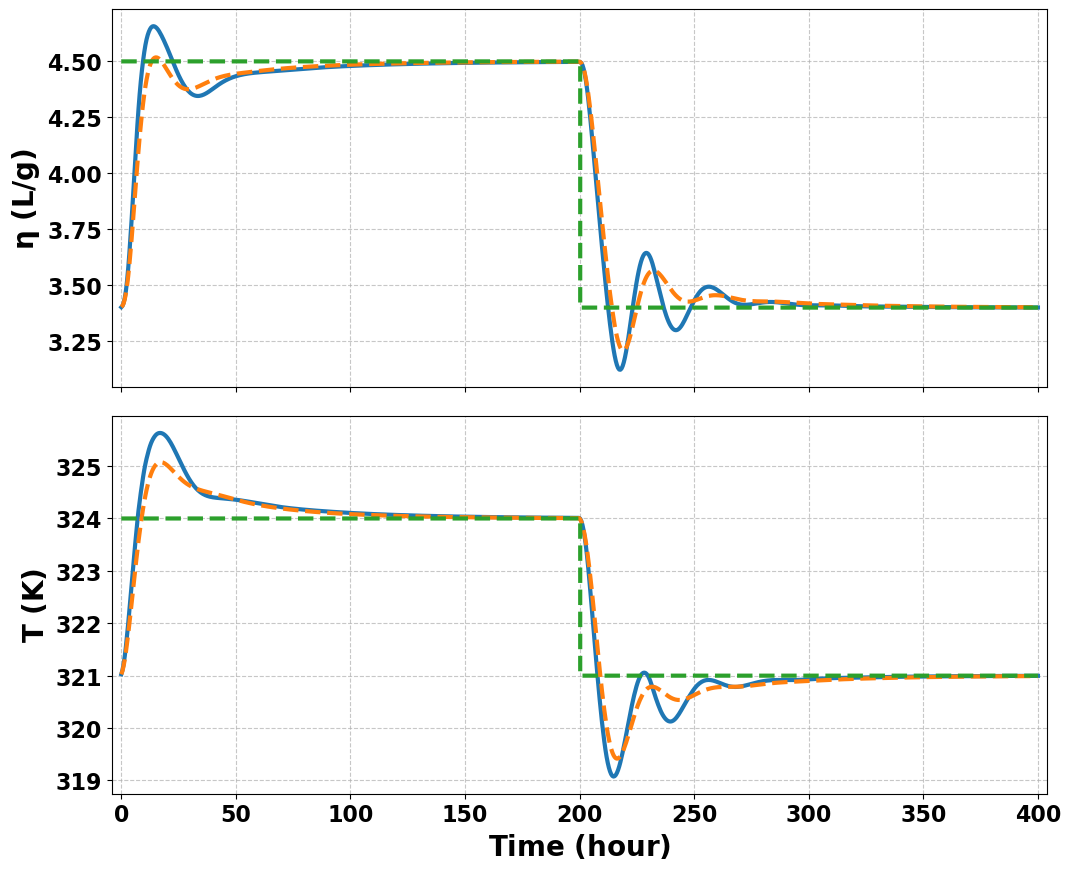

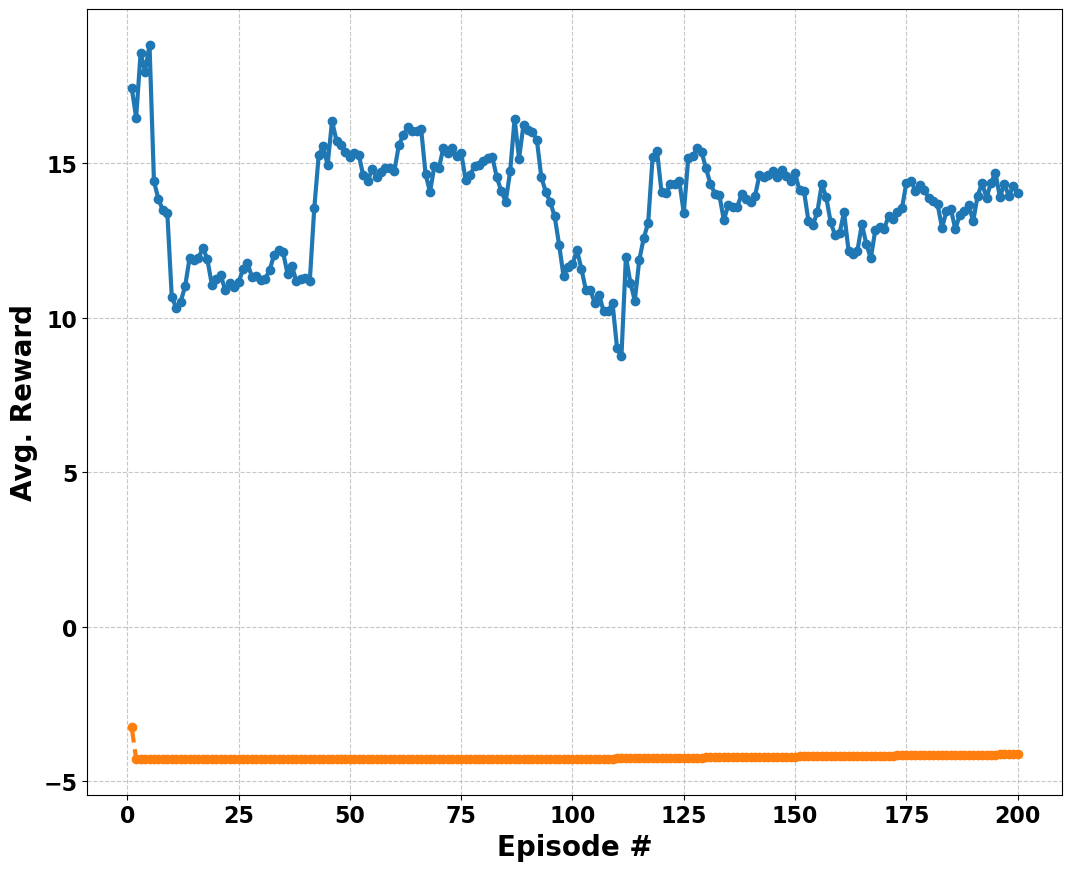

In [33]:
compare_mpc_rl_disturbance(y_system, y_mpc, y_sp, avg_rewards, avg_rewards_mpc, time_in_sub_episodes, delta_t)

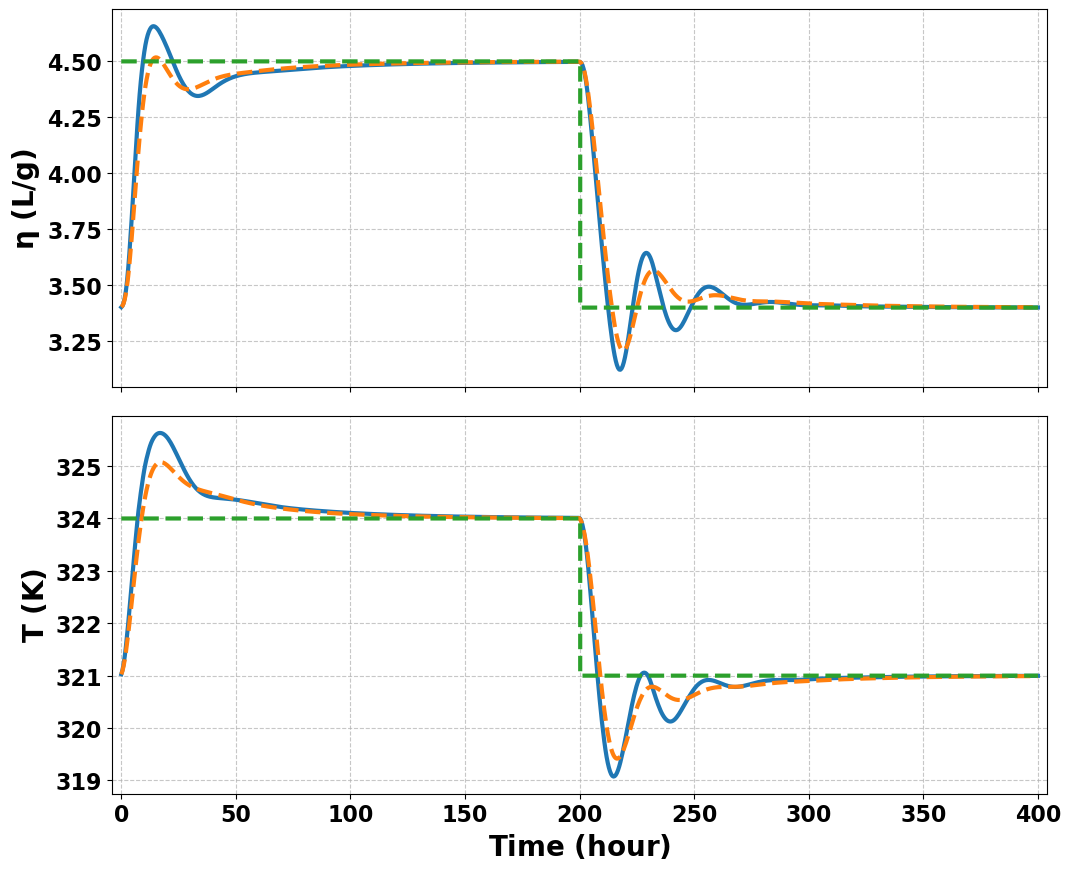

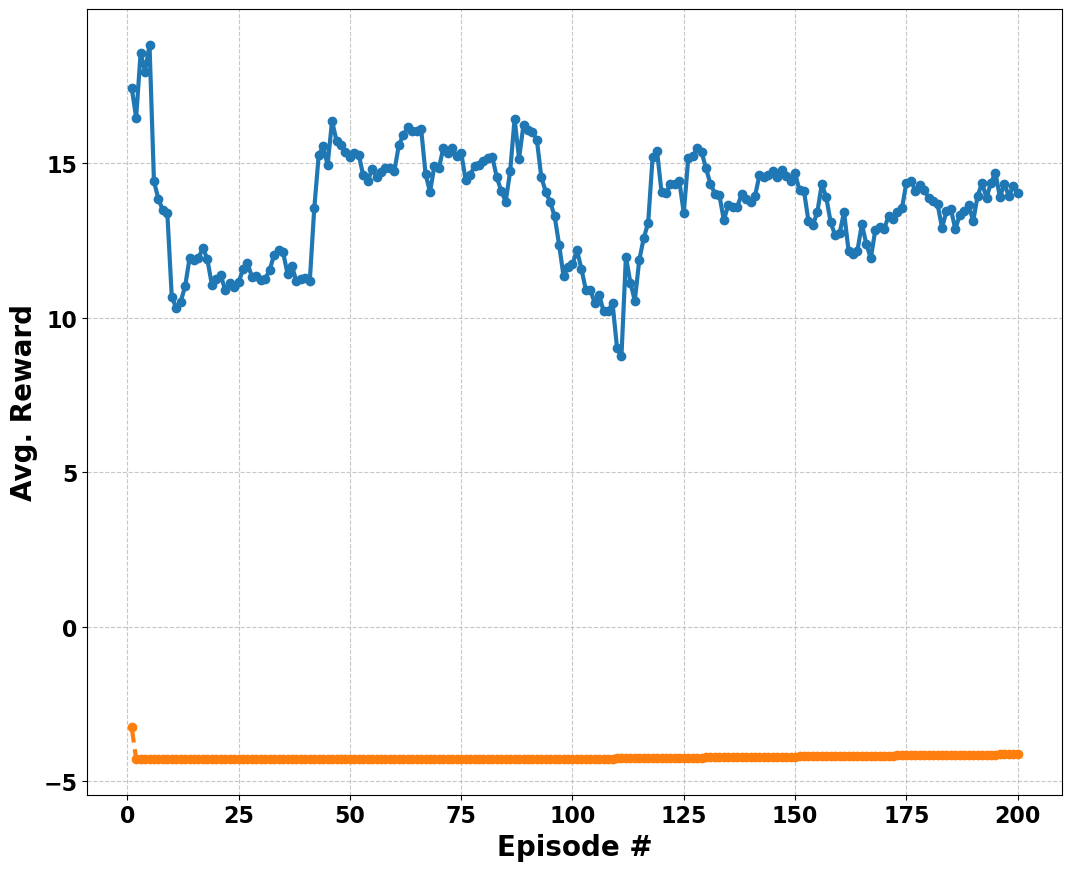

In [34]:
compare_mpc_rl_disturbance(y_system, y_mpc, y_sp, avg_rewards, avg_rewards_mpc, time_in_sub_episodes, delta_t)